# S43. Analogias Didaticas - Intervalo de Confianca (Confidence Interval)
## Uma abordagem intuitiva com analogias de sala de aula


[◀ Anterior](S42_Teste_Media_Bicaudal.ipynb) | [📖 Indice](S00_Index_Estatistica.ipynb) | [Proximo ▶](S00_Index_Estatistica.ipynb)


## 🎯 Objetivos de Aprendizagem

Ao final deste notebook, voce sera capaz de:

- Compreender o conceito de intervalo de confianca usando a analogia da cesta de lixo
- Visualizar como amostras diferentes produzem estimativas diferentes
- Entender o que significa "95% de confianca" na pratica
- Relacionar tamanho da amostra, variabilidade e amplitude do IC
- Construir e interpretar intervalos de confianca com Python


## 📝 Introducao

### 🏀 A Analogia da Cesta de Lixo

Imagine que voce esta a **5 metros** de distancia de um cesto de lixo e comeca a
arremessar bolinhas de papel. Voce joga **20 bolinhas**. O que acontece?

- Apenas **4 ou 5** caem dentro do cesto
- A maioria das bolinhas erra, mas fica **no entorno** do cesto
- Algumas bolinhas vao longe, outras chegam perto

Agora, em vez de 5 metros, voce aproxima o cesto para **2,5 metros**.
O que muda?

- A maioria das bolinhas acerta
- So 1 ou 2 erram
- Os erros sao **menores** — as bolinhas ficam muito mais proximas do cesto

Essa experiencia simples tem tudo a ver com **intervalo de confianca**!
Vamos entender por que.


## 📚 Explicacao Detalhada

### Traduzindo a Analogia para a Estatistica

| Elemento da Analogia | Conceito Estatistico |
|---------------------|---------------------|
| **Cesto de lixo** | A **verdadeira media** populacional (μ) — o valor real que queremos estimar |
| **Cada arremesso** | Uma **amostra** que coletamos da populacao |
| **Onde a bolinha cai** | A **estimativa** que cada amostra produz (x̄) |
| **A distancia do cesto** | O **erro amostral** — quanto a estimativa se afasta do valor real |
| **A dispersao das bolinhas** | A **variabilidade amostral** (erro padrao) |
| **A "rede" em volta do cesto** | O **intervalo de confianca** |

### 🎯 O Conceito Central

O **cesto** (a verdadeira media) esta sempre no **mesmo lugar**.
Nos nao sabemos exatamente onde ele esta — senao nao precisariamos estimar!
Mas sabemos que, se arremessarmos varias vezes (coletarmos varias amostras),
as bolinhas (as estimativas) vao se distribuir ao redor do cesto.

### 📏 O que a DISTANCIA representa?

Pense na seguinte ideia: quando aproximamos o cesto, nossos arremessos ficam 
Em Estatistica, nos **nao podemos mover o cesto** (o parametro verdadeiro 
O que reduz a dispersao?

1. **Aumentar o numero de arremessos (tamanho da amostra)** — quanto mais   dados, mais precisa e a estimativa
2. **Reduzir a variabilidade natural dos dados** — populacoes mais   homogeneas produzem estimativas mais precisas

Na analogia, **"trazer o cesto para mais perto"** representa na pratica:
coletar **mais dados** ou trabalhar com dados **menos dispersos**.
O resultado e o mesmo: um **intervalo de confianca mais estreito**
(mais preciso) para o mesmo nivel de confianca.

### 🔢 Os Dois Fatores que Controlam o IC

O intervalo de confianca para a media tem esta formula:

> **IC = x̄ ± t × (s / √n)**

Onde:
- **x̄** = media da amostra (onde nossa bolinha caiu)
- **t** = valor critico (define o tamanho da "rede" — depende do nivel de confianca escolhido)
- **s / √n** = erro padrao (a dispersao dos arremessos)
- **n** = tamanho da amostra (quantidade de arremessos)

| Acao | Efeito no IC | Analogia |
|------|-------------|----------|
| Aumentar n (mais arremessos) | IC mais estreito (mais preciso) | Praticar mais arremessos melhora a pontaria |
| Reduzir s (menos variabilidade) | IC mais estreito | Bolinhas mais uniformes (mesmo peso, mesmo tamanho) |
| Aumentar a confianca (95% → 99%) | IC mais largo (mais conservador) | Usar uma rede maior para ter mais certeza |
| Diminuir a confianca (95% → 90%) | IC mais estreito (menos certeza) | Usar uma rede menor, aceitando mais risco de errar |


In [1]:
# Importando bibliotecas
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 💻 Exemplos Praticos

Vamos simular a analogia da cesta de lixo com Python!

A ideia e simples: vamos "arremessar" estimativas (medias amostrais) em direcao ao valor verdadeiro (o cesto) e ver como o intervalo de confianca se comporta.


### 📦 Exemplo 1: Simulando a Cesta de Lixo

Vamos supor que o **valor verdadeiro** (o cesto) esta em μ = 100.
Vamos "arremessar" 30 amostras, cada uma com n = 20 observacoes.
Cada arremesso produz uma media amostral (x̄) — aonde a bolinha caiu.
Para cada arremesso, vamos desenhar o intervalo de confianca de 95%.

Vamos ver quantos intervalos "acertam o cesto" (contem o valor verdadeiro).


In [2]:
# Configuracao da simulacao
np.random.seed(42)
mu_verdadeiro = 100      # posicao do cesto (parametro verdadeiro)
sigma = 15                # desvio padrao da populacao
n = 20                    # tamanho de cada amostra (arremessos por rodada)
n_amostras = 50           # numero de arremessos (amostras)

# Arremessando!
medias = []
ics = []
acertou = []

for i in range(n_amostras):
    amostra = np.random.normal(mu_verdadeiro, sigma, n)
    x_bar = np.mean(amostra)
    s = np.std(amostra, ddof=1)
    erro_padrao = s / np.sqrt(n)
    t_critico = stats.t.ppf(0.975, df=n-1)
    ic_inf = x_bar - t_critico * erro_padrao
    ic_sup = x_bar + t_critico * erro_padrao
    medias.append(x_bar)
    ics.append((ic_inf, ic_sup))
    acertou.append(ic_inf <= mu_verdadeiro <= ic_sup)

taxa_acerto = sum(acertou) / n_amostras * 100
print(f"De {n_amostras} arremessos (amostras):")
print(f"  Intervalos que ACERTARAM o cesto: {sum(acertou)} ({taxa_acerto:.1f}%)")
print(f"  Intervalos que ERRARAM o cesto: {n_amostras - sum(acertou)} ({100-taxa_acerto:.1f}%)")
print(f"\nO esperado para IC de 95% e que ~95% dos intervalos contenham o valor verdadeiro.")


De 50 arremessos (amostras):
  Intervalos que ACERTARAM o cesto: 46 (92.0%)
  Intervalos que ERRARAM o cesto: 4 (8.0%)

O esperado para IC de 95% e que ~95% dos intervalos contenham o valor verdadeiro.


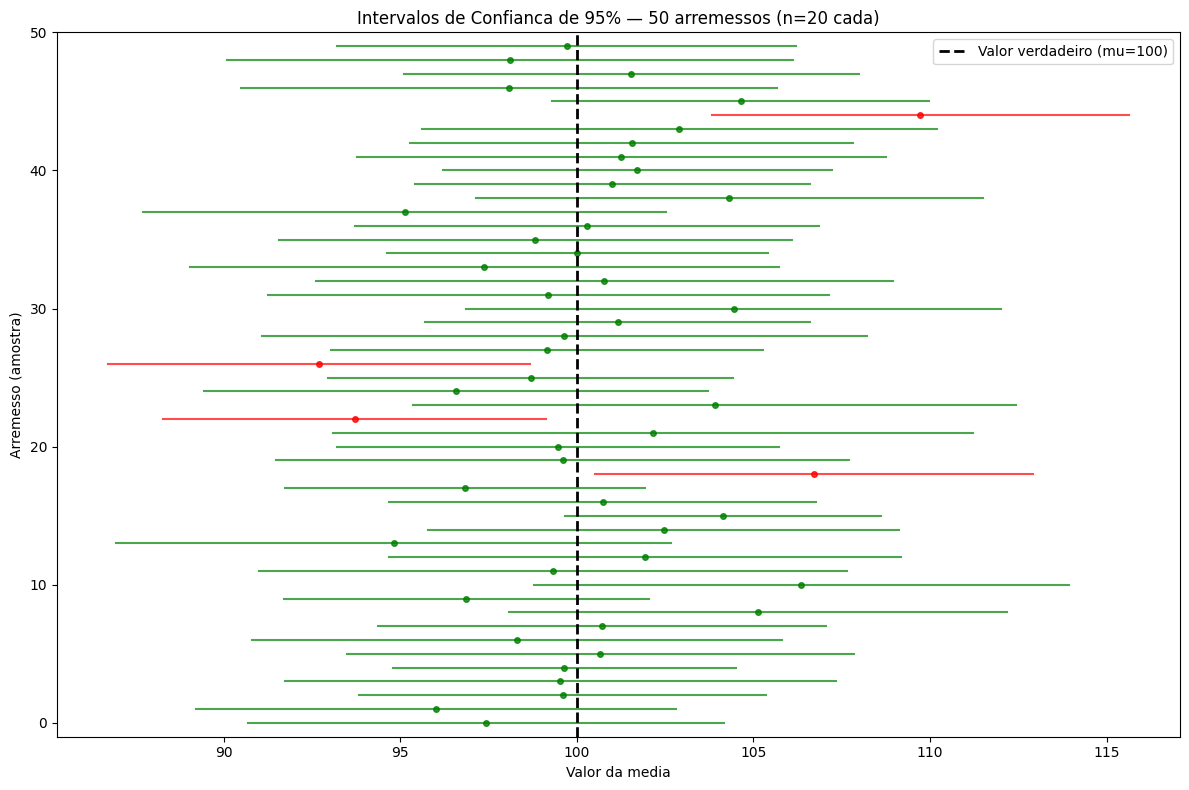


Legenda:
  Linha verde = IC que contem o cesto (acertou)
  Linha vermelha = IC que NAO contem o cesto (errou)
  Cada bolinha = onde a media amostral caiu
  Linha tracejada = posicao verdadeira do cesto (desconhecida na pratica)


In [3]:
# Visualizacao: cada linha e um arremesso, a barra e o IC
fig, ax = plt.subplots(figsize=(12, 8))

for i, (ic_inf, ic_sup) in enumerate(ics):
    cor = "green" if acertou[i] else "red"
    ax.plot([ic_inf, ic_sup], [i, i], color=cor, linewidth=1.5, alpha=0.7)
    ax.plot(medias[i], i, "o", color=cor, markersize=4, alpha=0.8)

ax.axvline(mu_verdadeiro, color="black", linestyle="--", linewidth=2, label=f"Valor verdadeiro (mu={mu_verdadeiro})")
ax.set_xlabel("Valor da media")
ax.set_ylabel("Arremesso (amostra)")
ax.set_title(f"Intervalos de Confianca de 95% — {n_amostras} arremessos (n={n} cada)")
ax.legend(loc="upper right", fontsize=10)
ax.set_ylim(-1, n_amostras)
plt.tight_layout()
plt.show()

print(f"\nLegenda:")
print(f"  Linha verde = IC que contem o cesto (acertou)")
print(f"  Linha vermelha = IC que NAO contem o cesto (errou)")
print(f"  Cada bolinha = onde a media amostral caiu")
print(f"  Linha tracejada = posicao verdadeira do cesto (desconhecida na pratica)")


### 📦 Exemplo 2: Mais Arremessos = Melhor Pontaria

Vamos comparar duas situacoes:

1. **Poucos arremessos:** n = 10 (analogia: cesto distante, 5m)
2. **Muitos arremessos:** n = 100 (analogia: cesto proximo, 2,5m)

A verdade e que **o cesto nao se moveu**! O que mudou foi a nossa
capacidade de estimar: com mais dados, nossos arremessos (estimativas)
ficam mais concentrados ao redor do valor verdadeiro.



Poucos arremessos (n = 10) — Cesto a 5m
  Erro padrao (sigma / sqrt(n)): 4.74
  Largura do IC de 95% (aprox.): 18.59

Muitos arremessos (n = 100) — Cesto a 2,5m
  Erro padrao (sigma / sqrt(n)): 1.50
  Largura do IC de 95% (aprox.): 5.88


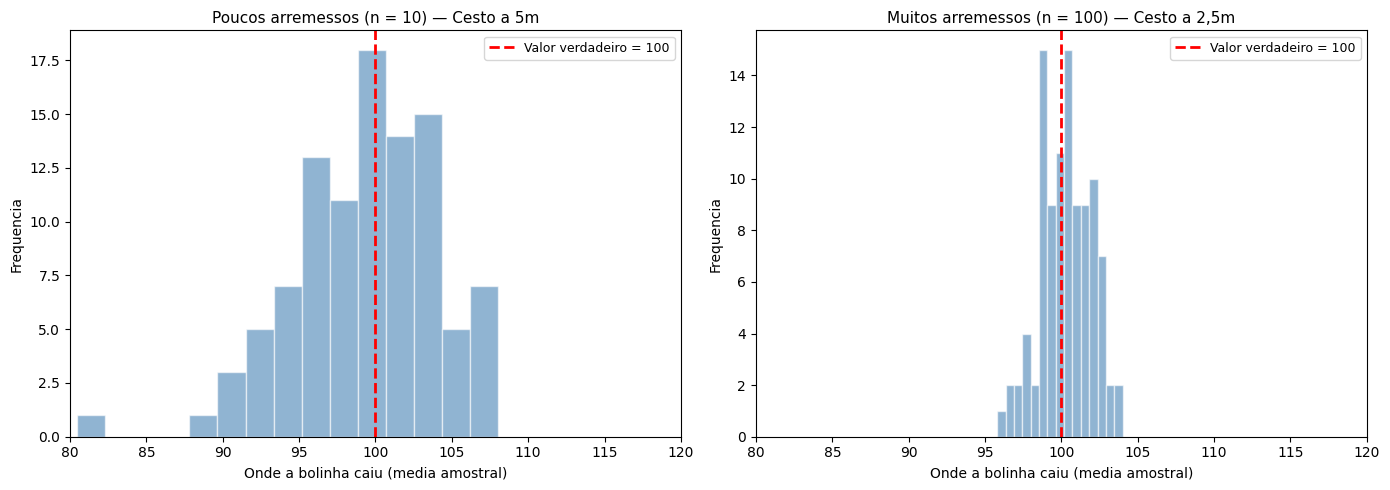


CONCLUSAO: Com mais dados (n maior), o erro padrao DIMINUI.
O intervalo de confianca fica MAIS ESTREITO (mais preciso).
E como se o cesto estivesse "mais perto" — nossos arremessos
variam menos ao redor do valor verdadeiro.


In [5]:
# Comparando n pequeno vs n grande
np.random.seed(123)
mu_real = 100
sigma = 15

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (n, titulo) in enumerate([
    (10, "Poucos arremessos (n = 10) — Cesto a 5m"),
    (100, "Muitos arremessos (n = 100) — Cesto a 2,5m")
]):
    n_sim = 100
    medias = []
    for _ in range(n_sim):
        amostra = np.random.normal(mu_real, sigma, n)
        medias.append(np.mean(amostra))
    
    axes[idx].hist(medias, bins=15, alpha=0.6, color="steelblue", edgecolor="white")
    axes[idx].axvline(mu_real, color="red", linestyle="--", linewidth=2, label=f"Valor verdadeiro = {mu_real}")
    axes[idx].set_xlabel("Onde a bolinha caiu (media amostral)")
    axes[idx].set_ylabel("Frequencia")
    axes[idx].set_title(titulo, fontsize=11)
    axes[idx].legend(fontsize=9)
    axes[idx].set_xlim(80, 120)
    
    # Calcular o IC medio
    erro_padrao = sigma / np.sqrt(n)
    print(f"\n{titulo}")
    print(f"  Erro padrao (sigma / sqrt(n)): {erro_padrao:.2f}")
    print(f"  Largura do IC de 95% (aprox.): {2 * 1.96 * erro_padrao:.2f}")

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CONCLUSAO: Com mais dados (n maior), o erro padrao DIMINUI.")
print("O intervalo de confianca fica MAIS ESTREITO (mais preciso).")
print("E como se o cesto estivesse \"mais perto\" — nossos arremessos")
print("variam menos ao redor do valor verdadeiro.")
print("="*60)


### 📦 Exemplo 3: Rede Maior = Mais Certeza

O nivel de confianca e como o **tamanho da rede** que colocamos em volta do cesto.

- IC de 90% = rede pequena (mais risco de errar, mais precisa)
- IC de 95% = rede media (padrao)
- IC de 99% = rede grande (quase certeza, mas menos precisa)

Vamos visualizar a diferenca!


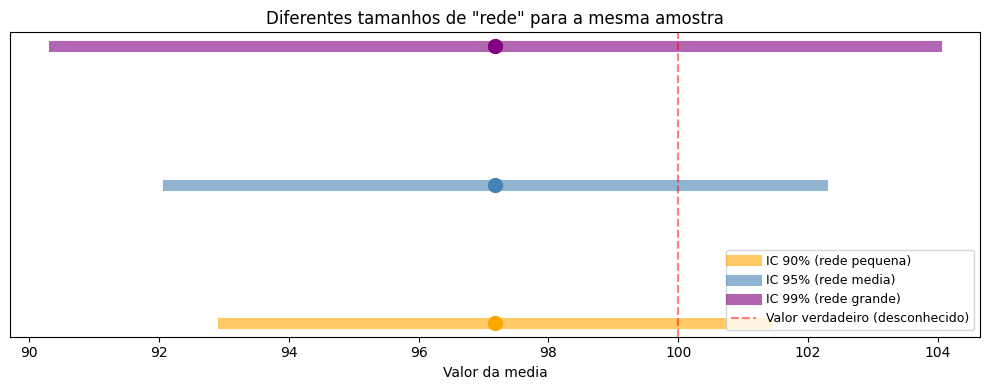

Media amostral: 97.18

Quanto MAIOR a confianca desejada, MAIS LARGO o intervalo.
E como usar uma rede maior para ter mais certeza de que vai pegar o cesto!


In [7]:
# Comparando niveis de confianca
np.random.seed(42)
n = 30
amostra = np.random.normal(100, 15, n)
x_bar = np.mean(amostra)
s = np.std(amostra, ddof=1)
erro_padrao = s / np.sqrt(n)

niveis = [0.90, 0.95, 0.99]
cores = ["orange", "steelblue", "purple"]
labels = ["IC 90% (rede pequena)", "IC 95% (rede media)", "IC 99% (rede grande)"]

fig, ax = plt.subplots(figsize=(10, 4))

y_pos = 0
for nivel, cor, label in zip(niveis, cores, labels):
    t_crit = stats.t.ppf(1 - (1-nivel)/2, df=n-1)
    margem = t_crit * erro_padrao
    ax.plot([x_bar - margem, x_bar + margem], [y_pos, y_pos],
            color=cor, linewidth=8, alpha=0.6, label=label)
    ax.plot(x_bar, y_pos, "o", color=cor, markersize=10, zorder=5)
    y_pos += 1

ax.axvline(100, color="red", linestyle="--", alpha=0.5, label="Valor verdadeiro (desconhecido)")
ax.set_yticks([])
ax.set_xlabel("Valor da media")
ax.set_title("Diferentes tamanhos de \"rede\" para a mesma amostra")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

print(f"Media amostral: {x_bar:.2f}")
print(f"\nQuanto MAIOR a confianca desejada, MAIS LARGO o intervalo.")
print("E como usar uma rede maior para ter mais certeza de que vai pegar o cesto!")


### 📦 Exemplo 4: Simulando 1000 Cestas (Coverage)

Vamos repetir o experimento 1000 vezes para verificar:
quantos intervalos de 95% realmente contem o valor verdadeiro?

Isso e o que significa **"95% de confianca"** na pratica.


In [8]:
# Simulacao de cobertura — 1000 experimentos
np.random.seed(42)
mu_real = 100
sigma = 15
n = 25
n_sim = 1000

contem = 0
for _ in range(n_sim):
    amostra = np.random.normal(mu_real, sigma, n)
    x_bar = np.mean(amostra)
    s = np.std(amostra, ddof=1)
    t_crit = stats.t.ppf(0.975, df=n-1)
    ic_inf = x_bar - t_crit * s / np.sqrt(n)
    ic_sup = x_bar + t_crit * s / np.sqrt(n)
    if ic_inf <= mu_real <= ic_sup:
        contem += 1

print(f"Simulacao de {n_sim} experimentos (IC de 95%, n={n} cada):")
print(f"  Intervalos que contem o valor verdadeiro: {contem}")
print(f"  Taxa de cobertura: {contem/n_sim*100:.1f}%")
print(f"  Esperado: ~95%")
print()
print("Esta e a essencia do intervalo de confianca:")
print("SE repetirmos o experimento muitas vezes, ~95% dos intervalos")
print("construidos conterao o verdadeiro valor populacional.")
print("Nao podemos garantir que UM unico intervalo especifico acertou,")
print("mas podemos confiar no PROCESSO!")


Simulacao de 1000 experimentos (IC de 95%, n=25 cada):
  Intervalos que contem o valor verdadeiro: 954
  Taxa de cobertura: 95.4%
  Esperado: ~95%

Esta e a essencia do intervalo de confianca:
SE repetirmos o experimento muitas vezes, ~95% dos intervalos
construidos conterao o verdadeiro valor populacional.
Nao podemos garantir que UM unico intervalo especifico acertou,
mas podemos confiar no PROCESSO!


## ✅ Exercicios Resolvidos


**Exercicio 1:** Voce coletou uma amostra de 36 estudantes e obteve media de
altura de 168 cm com desvio padrao de 12 cm. Construa o IC de 95%.

Use a formula: IC = x̄ ± t × (s / √n)


In [10]:
# Solucao Exercicio 1
n = 36
x_bar = 168.0
s = 12.0
t_crit = stats.t.ppf(0.975, df=n-1)
erro = t_crit * s / np.sqrt(n)

print(f"Media amostral: {x_bar} cm")
print(f"Desvio padrao: {s} cm")
print(f"Valor critico t: {t_crit:.4f}")
print(f"Erro padrao: {s/np.sqrt(n):.2f}")
print(f"Margem de erro: {erro:.2f} cm")
print(f"IC 95%: [{x_bar - erro:.2f}, {x_bar + erro:.2f}] cm")
print()
print("Interpretacao: Temos 95% de confianca de que a altura media")
print("verdadeira dos estudantes esta entre", f"{x_bar - erro:.2f} e {x_bar + erro:.2f} cm.")

Media amostral: 168.0 cm
Desvio padrao: 12.0 cm
Valor critico t: 2.0301
Erro padrao: 2.00
Margem de erro: 4.06 cm
IC 95%: [163.94, 172.06] cm

Interpretacao: Temos 95% de confianca de que a altura media
verdadeira dos estudantes esta entre 163.94 e 172.06 cm.


## 📋 Exercicios Propostos

Tente resolver sem consultar a resposta! Use a analogia da cesta de lixo
para pensar sobre cada problema.


### 🟢 Exercicio 1 — Facil

Uma maquina de refrigerante enche copos com desvio padrao de 5 mL.
Uma amostra de 16 copos teve media de 300 mL.
Construa o IC de 95% para o volume medio verdadeiro.


### 🟡 Exercicio 2 — Medio

Usando os mesmos dados do Exercicio 1, construa o IC de 99%.
O que aconteceu com a largura do intervalo? Por que?

Depois, refaca com n = 64 (mesma media e desvio).
O que mudou? Relacione com a analogia das bolinhas.


## 🏆 Desafios

**Desafio 1:** Explique com suas palavras a analogia da cesta de lixo
para um colega que nunca estudou estatistica.

**Desafio 2:** Se o IC de 95% para a altura media e [165, 171],
podemos afirmar que 95% dos individuos tem altura entre 165 e 171?
Por que? (Dica: intervalo de confianca != intervalo de predicao)

**Desafio 3:** Crie SUA propria analogia para intervalo de confianca
e compartilhe com a turma!


## 📌 Resumo

- O intervalo de confianca e uma **faixa de valores** que contem o
  parametro verdadeiro com determinado nivel de confianca
- **Nao** significa que ha 95% de chance de o parametro estar no intervalo
  (o parametro e fixo, quem varia sao as amostras)
- Significa que, **se repetirmos o processo** muitas vezes, 95% dos
  intervalos construidos conterao o valor verdadeiro
- **Amostras maiores** → IC mais estreito (como aproximar o cesto)
- **Maior confianca** → IC mais largo (como usar uma rede maior)
- **Menor variabilidade** → IC mais estreito (arremessos mais precisos)

A analogia da cesta de lixo nos ajuda a lembrar:

> O cesto (parametro) esta la. Nosso trabalho e arremessar bem
> (coletar boas amostras) e usar a rede certa (nivel de confianca adequado)
> para ter uma boa estimativa de onde ele esta.


## 📖 Referencias

- [W3Schools Statistics - Confidence Intervals](https://www.w3schools.com/statistics/statistics_confidence_interval.php)
- [W3Schools Statistics - Estimating Population Mean](https://www.w3schools.com/statistics/statistics_estimation_mean.php)
- Documentacao SciPy: `scipy.stats.t.interval`
- Documentacao NumPy: `numpy.random.normal`

---

> *"A estatistica e a arte de nunca ter que dizer que esta certo,
> mas sim o quanto voce confia que esta perto da verdade."*
> — Adaptado de Confianca vs Precisao


[◀ Anterior](S42_Teste_Media_Bicaudal.ipynb) | [📖 Indice](S00_Index_Estatistica.ipynb) | [Proximo ▶](S00_Index_Estatistica.ipynb)
